# Probability that the youngest Titanic Survivor lives the longest

In [27]:
import pandas as pd

df = pd.read_csv('data/titanic_updated.csv')

# Survivors by Age

In [28]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,NewSurvived,NewPclass
0,1.0,0,3.0,"Braund, Mr. Owen Harris",male,22.00,1.0,0.0,A/5 21171,7.2500,NaN,S,Perished,Third
1,2.0,1,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1.0,0.0,PC 17599,71.2833,C85,C,Survived,First
2,3.0,1,3.0,"Heikkinen, Miss. Laina",female,26.00,0.0,0.0,STON/O2. 3101282,7.9250,NaN,S,Survived,Third
3,4.0,1,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1.0,0.0,113803,53.1000,C123,S,Survived,First
4,5.0,0,3.0,"Allen, Mr. William Henry",male,35.00,0.0,0.0,373450,8.0500,NaN,S,Perished,Third
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,888.0,1,1.0,"Graham, Miss. Margaret Edith",female,19.00,0.0,0.0,112053,30.0000,B42,S,Survived,First
888,889.0,0,3.0,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1.0,2.0,W./C. 6607,23.4500,NaN,S,Perished,Third
889,890.0,1,1.0,"Behr, Mr. Karl Howell",male,26.00,0.0,0.0,111369,30.0000,C148,C,Survived,First
890,891.0,0,3.0,"Dooley, Mr. Patrick",male,32.00,0.0,0.0,370376,7.7500,NaN,Q,Perished,Third


# Survivors by Age

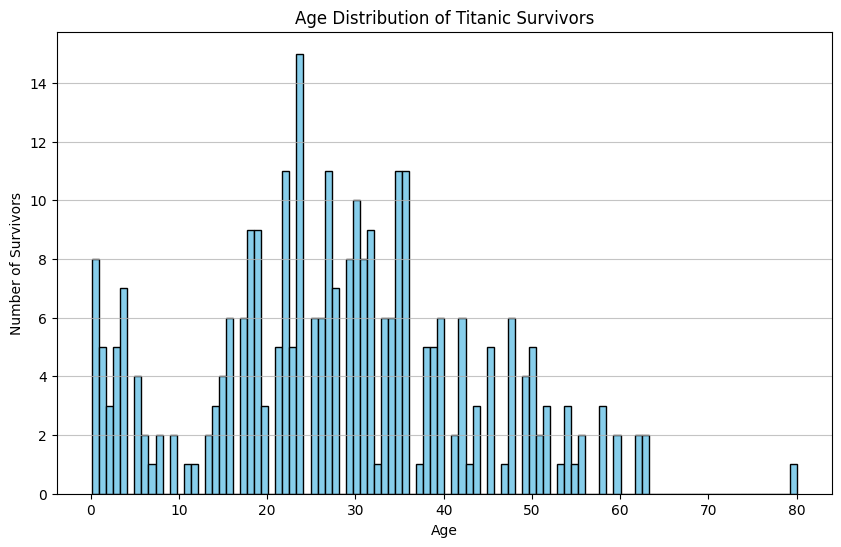

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter for survivors
survivors = df[df['Survived'] == 1]

# Drop rows with missing ages
survivors = survivors.dropna(subset=['Age'])

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(survivors['Age'], bins=100, color='skyblue', edgecolor='black')
plt.title("Age Distribution of Titanic Survivors")
plt.xlabel("Age")
plt.ylabel("Number of Survivors")
plt.grid(axis='y', alpha=0.75)
plt.show()


## Who is the youngest survivor?

In [31]:
# Filter to survivors with known age
survivors = df[(df['Survived'] == 1) & df['Age'].notna()]

# Sort by age and get the youngest 10
youngest_10 = survivors.sort_values(by='Age').head(10)

# Display name and age
print(youngest_10[['Name', 'Age']])


                                Name   Age
891         Dean, Miss. Eliza Gladys  0.17
803  Thomas, Master. Assad Alexander  0.42
755        Hamalainen, Master. Viljo  0.67
644           Baclini, Miss. Eugenie  0.75
469    Baclini, Miss. Helene Barbara  0.75
78     Caldwell, Master. Alden Gates  0.83
831  Richards, Master. George Sibley  0.83
305   Allison, Master. Hudson Trevor  0.92
172     Johnson, Miss. Eleanor Ileen  1.00
183        Becker, Master. Richard F  1.00


# Average Lifespan

For UK, USA, and Ireland, in 1912, we assume an average lifespan of 76 years for women, and 70 years for men. We also use some standard deviations.

| Sex       | Avg. Age at Time of Disaster | Estimated Additional Life (Post-1912) | **Estimated Total Lifespan** |
| --------- | ---------------------------- | ------------------------------------- | ---------------------------- |
| 👩 Female | \~24 years                   | \~52 years                            | **\~76 years**               |
| 👨 Male   | \~28 years                   | \~42 years                            | **\~70 years**               |


| Group                | Estimated Mean Lifespan | Recommended SD |
| -------------------- | ----------------------- | -------------- |
| **Female Survivors** | \~76 years              | **≈ 12 years** |
| **Male Survivors**   | \~70 years              | **≈ 15 years** |


# Simulate Lifespan Scenarios

In [33]:
import pandas as pd
import numpy as np

# Filter valid survivors with age and sex info
survivors = df[(df['Survived'] == 1) & df['Age'].notna() & df['Sex'].notna()]

# Reset index for easy lookup
survivors = survivors.reset_index(drop=True)

# Parameters
n_simulations = 10000
count_youngest_lives_longest = 0

# Precompute mean and SD by sex
mean_sd_by_sex = {
    'female': {'mean': 76, 'sd': 12},
    'male': {'mean': 70, 'sd': 15}
}

# Get the index of the youngest survivor
youngest_idx = survivors['Age'].idxmin()

# Run simulation
for _ in range(n_simulations):
    simulated_lifespans = []

    for i, row in survivors.iterrows():
        sex = row['Sex'].lower()
        age_at_disaster = row['Age']
        mean = mean_sd_by_sex[sex]['mean']
        sd = mean_sd_by_sex[sex]['sd']

        # Simulate total lifespan, then subtract current age to get remaining life
        total_life = np.random.normal(loc=mean, scale=sd)
        # Clip unrealistic values
        total_life = np.clip(total_life, age_at_disaster, 110)
        simulated_lifespans.append(total_life)

    # Check if youngest survivor has the longest simulated lifespan
    if np.argmax(simulated_lifespans) == youngest_idx:
        count_youngest_lives_longest += 1

# Final result
probability = count_youngest_lives_longest / n_simulations
print(f"Estimated probability that the youngest survivor lives the longest: {probability:.5f}")


Estimated probability that the youngest survivor lives the longest: 0.00310
